In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from google.colab import files

uploaded = files.upload()

Saving Real_Cases.csv to Real_Cases (1).csv


In [24]:
df = pd.read_csv('Real_Cases.csv')
print(df.head())      # first 5 rows


  Golfer ID  Age Club Type  Handicap  Speed (mph)  Launch Angle  Push (yds)  \
0      WA-1   17    Driver      -1.8        135.0          11.7         4.9   
1      WA-2   16    Driver       2.8        123.0          12.2         7.7   
2      WA-3   56    Driver      17.0         84.1          31.4        13.0   
3      WA-4   66    Driver      16.8        116.0          16.0        -7.2   
4      WA-5   65    Driver      13.0         95.9          17.3         2.2   

   Carry (yds)  Total Spin (rpm)  Spin Axis  
0        207.0              4274          0  
1        189.0              2649         13  
2        108.0              4874         17  
3        175.0              3674          9  
4        130.0              4025          2  


In [25]:
df = df.rename(columns={
    'Speed (mph)': 'Speed',
    'Launch Angle (°)': 'Launch Angle',
    'Carry (yds)': 'Carry',
    'Total Spin (rpm)': 'Total Spin','Spin Axis (°)':'Spin Axis', 'Push (yds)':'Push'
})

In [26]:
df = df[df["Carry"] > 0]

print(f"Remaining observations: {len(df)}")

print(df.info())

print()

df.describe().T

Remaining observations: 58
<class 'pandas.core.frame.DataFrame'>
Index: 58 entries, 0 to 58
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Golfer ID     58 non-null     object 
 1   Age           58 non-null     int64  
 2   Club Type     58 non-null     object 
 3   Handicap      58 non-null     float64
 4   Speed         58 non-null     float64
 5   Launch Angle  58 non-null     float64
 6   Push          58 non-null     float64
 7   Carry         58 non-null     float64
 8   Total Spin    58 non-null     int64  
 9   Spin Axis     58 non-null     int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 5.0+ KB
None



,count,mean,std,min,25%,50%,75%,max
Age,58.0,37.741379,22.114979,15.0,18.000,21.00,59.000,80.0
Handicap,58.0,6.458621,8.070306,-4.5,0.425,4.15,12.775,30.5
Speed,58.0,121.893103,16.373094,83.6,110.500,125.00,134.000,150.0
Launch Angle,58.0,13.548276,4.106488,3.6,11.800,13.40,15.450,31.4
Push,58.0,4.744828,5.505155,-8.8,1.675,5.40,8.425,16.0
Carry,58.0,180.715517,41.805850,99.5,149.250,187.50,214.750,252.0
Total Spin,58.0,3213.706897,876.150152,950.0,2656.250,3250.00,4006.000,4874.0
Spin Axis,58.0,2.137931,18.408092,-46.0,-9.000,3.00,16.500,38.0


In [27]:
print(df.isnull().sum())

Golfer ID       0
Age             0
Club Type       0
Handicap        0
Speed           0
Launch Angle    0
Push            0
Carry           0
Total Spin      0
Spin Axis       0
dtype: int64


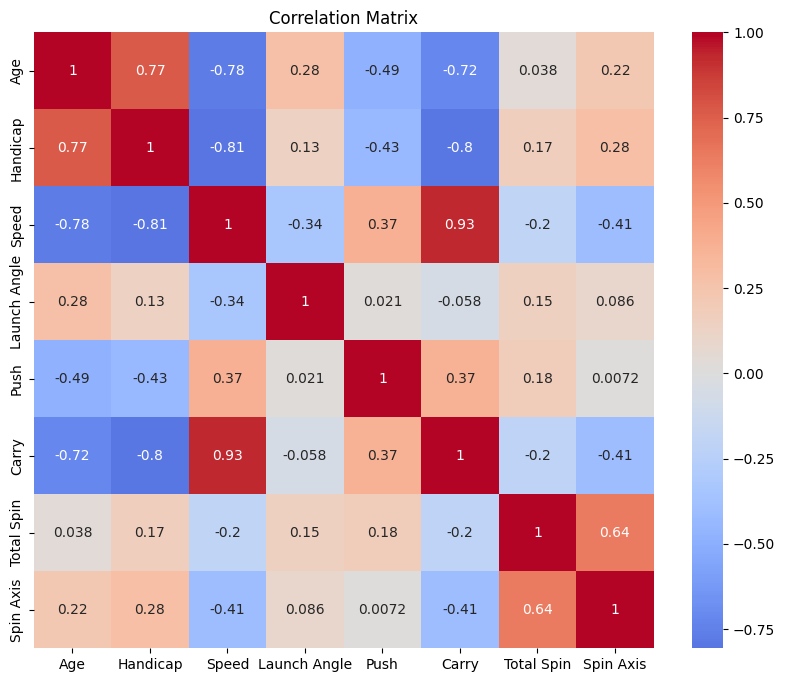

<Figure size 640x480 with 0 Axes>

In [28]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            center=0)

plt.title("Correlation Matrix")
plt.show()

plt.savefig("corr_matrix.png", dpi=300, bbox_inches="tight")

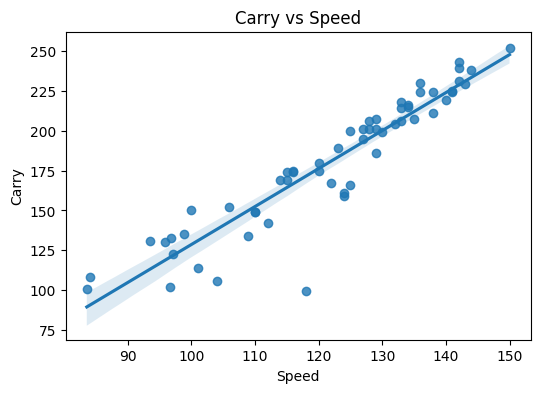

<Figure size 640x480 with 0 Axes>

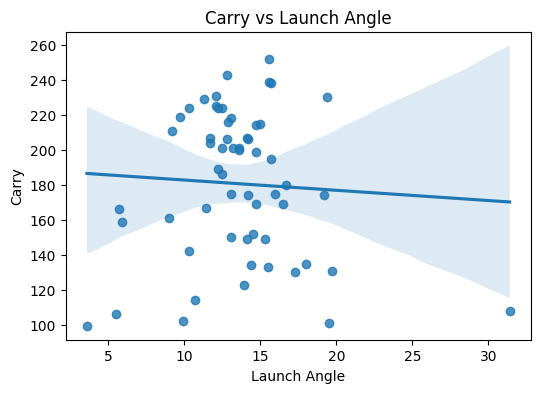

<Figure size 640x480 with 0 Axes>

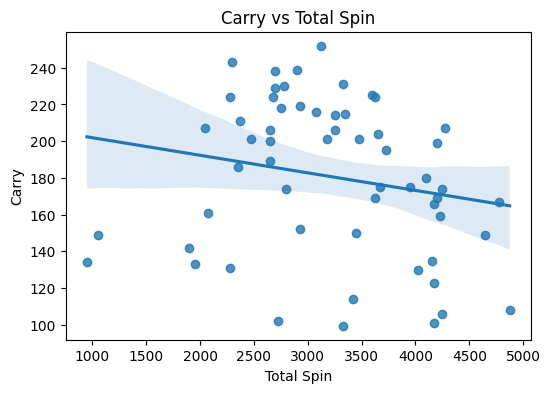

<Figure size 640x480 with 0 Axes>

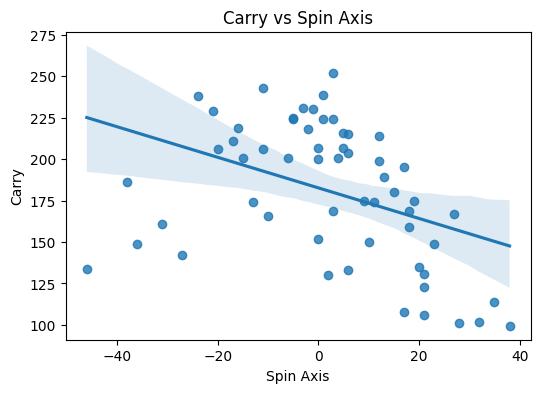

<Figure size 640x480 with 0 Axes>

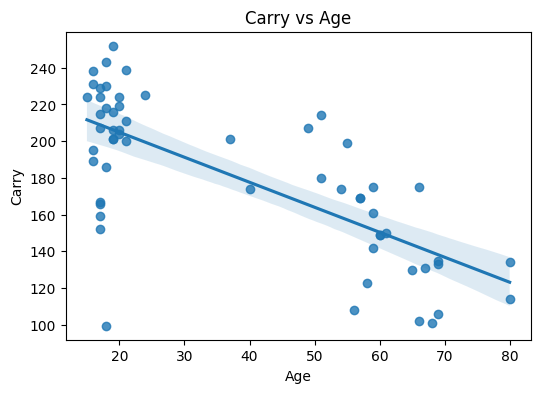

<Figure size 640x480 with 0 Axes>

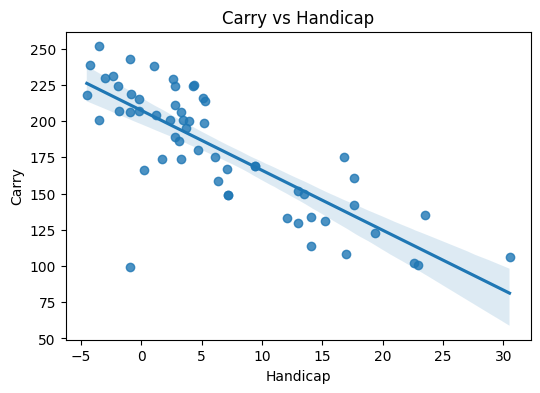

<Figure size 640x480 with 0 Axes>

In [29]:
variables = [
    "Speed",
    "Launch Angle",
    "Total Spin",
    "Spin Axis",
    "Age",
    "Handicap"
]

for variable in variables:

    plt.figure(figsize=(6,4))

    sns.regplot(
        data=df,
        x=variable,
        y="Carry"
    )

    plt.title(f"Carry vs {variable}")

    plt.show()

    plt.savefig("carry_vs_speed.png", dpi=300, bbox_inches="tight")

In [30]:
model1 = smf.ols(
    "Carry ~ Speed",
    data=df
).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Carry   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     372.5
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           2.04e-26
Time:                        20:12:19   Log-Likelihood:                -239.30
No. Observations:                  58   AIC:                             482.6
Df Residuals:                      56   BIC:                             486.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -109.4670     15.168     -7.217      0.0

In [31]:
model2 = smf.ols(
    "Carry ~ Speed + Q('Launch Angle') + Q('Total Spin') + Q('Spin Axis') + Age + Handicap",
    data=df
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Carry   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     149.3
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.45e-30
Time:                        20:12:19   Log-Likelihood:                -213.59
No. Observations:                  58   AIC:                             441.2
Df Residuals:                      51   BIC:                             455.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          -168.6260     26.03

In [32]:
print(model2.params)

Intercept           -168.626016
Speed                  2.606611
Q('Launch Angle')      3.020498
Q('Total Spin')       -0.002684
Q('Spin Axis')         0.059799
Age                   -0.016390
Handicap              -0.029672
dtype: float64


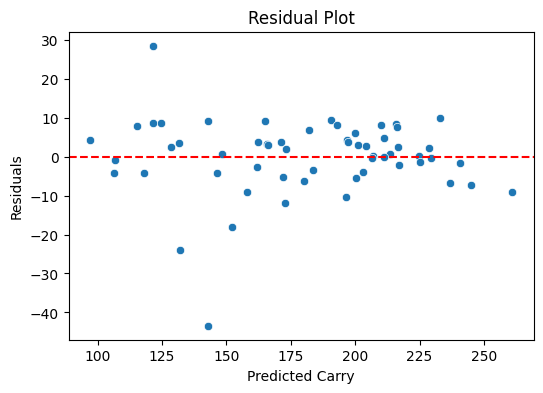

<Figure size 640x480 with 0 Axes>

In [33]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=model2.fittedvalues,
    y=model2.resid
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Carry")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

plt.savefig("res_plot.png", dpi=300, bbox_inches="tight")

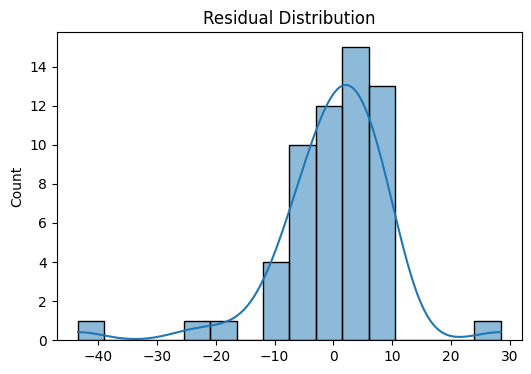

<Figure size 640x480 with 0 Axes>

In [34]:
plt.figure(figsize=(6,4))

sns.histplot(
    model2.resid,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

plt.savefig("res_dist.png", dpi=300, bbox_inches="tight")

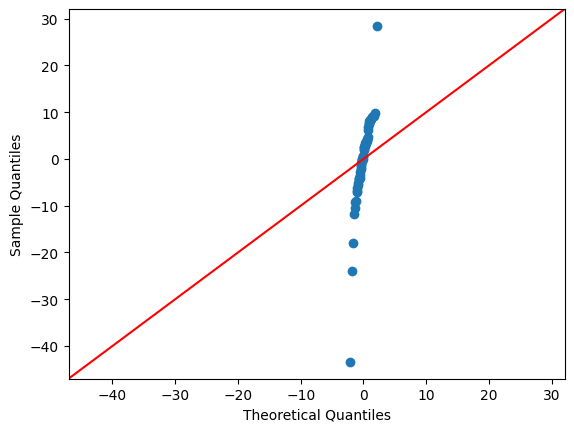

In [35]:
sm.qqplot(
    model2.resid,
    line='45'
)

plt.show()

In [36]:
shapiro = stats.shapiro(model2.resid)

print(shapiro)

ShapiroResult(statistic=np.float64(0.8530995472688999), pvalue=np.float64(5.143827569496485e-06))


In [37]:
influence = model2.get_influence()

summary = influence.summary_frame()

summary.head()

,dfb_Intercept,dfb_Speed,dfb_Q('Launch Angle'),dfb_Q('Total Spin'),dfb_Q('Spin Axis'),dfb_Age,dfb_Handicap,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,0.000155,-0.000520,-0.000901,0.002279,-0.001320,0.000180,-0.001180,0.000001,0.009381,0.093592,0.003014,0.009288,0.002985
1,0.114409,-0.063316,0.003337,-0.145839,0.123188,-0.142521,0.015502,0.007827,0.703037,0.099791,0.234074,0.699508,0.232899
2,-0.163947,0.727460,-2.148713,-0.659332,0.490571,0.945563,-0.299792,1.093805,-3.120333,0.440211,-2.767062,-3.434810,-3.045936
3,-0.099793,0.093596,0.043548,0.012066,0.018325,0.053626,0.069979,0.002637,0.395406,0.105615,0.135876,0.392112,0.134744
4,0.124143,-0.194520,-0.028406,0.192238,-0.194103,0.063551,-0.141697,0.016277,0.889837,0.125797,0.337552,0.887990,0.336851


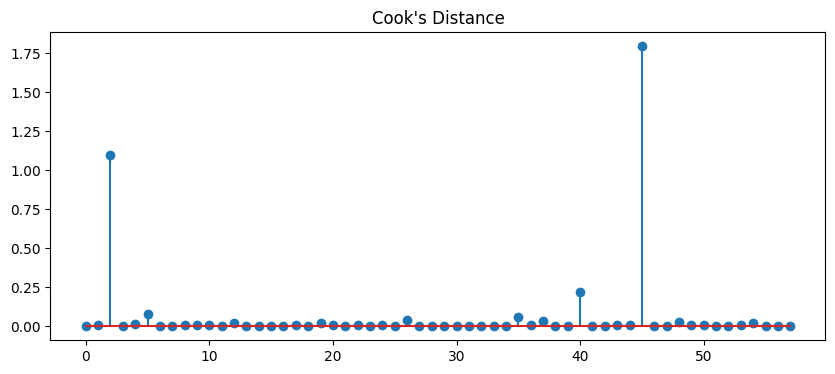

In [38]:
plt.figure(figsize=(10,4))

plt.stem(summary["cooks_d"])

plt.title("Cook's Distance")

plt.show()

In [39]:
X = df[[
    "Speed",
    "Launch Angle",
    "Total Spin",
    "Spin Axis",
    "Age",
    "Handicap"
]]

y = df["Carry"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.25,
    random_state=42
)

model = sm.OLS(
    y_train,
    sm.add_constant(X_train)
).fit()

predictions = model.predict(
    sm.add_constant(X_test)
)

print("R² =", r2_score(y_test,predictions))

print("RMSE =", np.sqrt(mean_squared_error(y_test,predictions)))

R² = 0.9213081829693673
RMSE = 10.511004360314676


In [40]:
coef = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values
})

coef

,Variable,Coefficient
0,const,-176.612243
1,Speed,2.661826
2,Launch Angle,3.203335
3,Total Spin,-0.002654
4,Spin Axis,0.014112
5,Age,-0.069122
6,Handicap,0.024772


In [42]:
group_summary = df.groupby("Age_Group").agg({
    "Carry":["mean","std"],
    "Speed":["mean","std"],
    "Launch Angle":["mean"],
    "Total Spin":["mean"],
    "Handicap":["mean"]
})

print(group_summary)

                Carry                  Speed            Launch Angle  \
                 mean        std        mean        std         mean   
Age_Group                                                              
50-59      164.909091  30.907781  114.936364  14.005733    15.381818   
60+        131.461538  21.654928  101.192308   8.583847    14.538462   
Under 50   204.661765  30.480178  132.058824   9.240691    12.576471   

            Total Spin   Handicap  
                  mean       mean  
Age_Group                          
50-59      3558.545455  10.309091  
60+        3133.846154  16.361538  
Under 50   3132.676471   1.426471  


In [43]:
# Create age groups
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 49, 59, 100],
    labels=["Under 50", "50-59", "60+"]
)

# Verify the groups
print(df["Age_Group"].value_counts())

Age_Group
Under 50    34
60+         13
50-59       11
Name: count, dtype: int64


In [45]:
summary = df.groupby("Age_Group").agg({
    "Age":["count","mean"],
    "Handicap":["mean","std"],
    "Speed":["mean","std"],
    "Carry":["mean","std"],
    "Launch Angle":["mean","std"],
    "Total Spin":["mean","std"],
    "Spin Axis":["mean","std"]
})

summary = summary.round(2)

summary

/tmp/ipykernel_4265/317391400.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("Age_Group").agg({


Age        Handicap         Speed          Carry         \
          count   mean     mean   std    mean    std    mean    std   
Age_Group                                                             
Under 50     34  20.38     1.43  3.71  132.06   9.24  204.66  30.48   
50-59        11  56.00    10.31  6.40  114.94  14.01  164.91  30.91   
60+          13  67.69    16.36  6.77  101.19   8.58  131.46  21.65   

          Launch Angle       Total Spin          Spin Axis         
                  mean   std       mean      std      mean    std  
Age_Group                                                          
Under 50         12.58  3.25    3132.68   669.31     -1.38  14.81  
50-59            15.38  5.80    3558.55   949.18      4.18  18.98  
60+              14.54  4.03    3133.85  1236.55      9.62  24.62

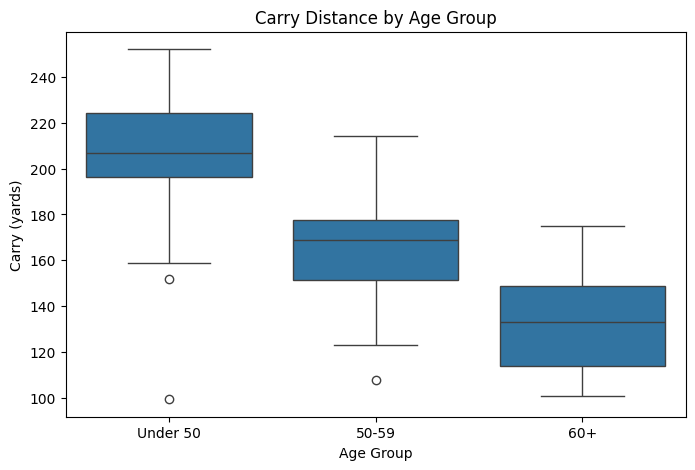

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Age_Group",
    y="Carry"
)

plt.title("Carry Distance by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Carry (yards)")
plt.show()

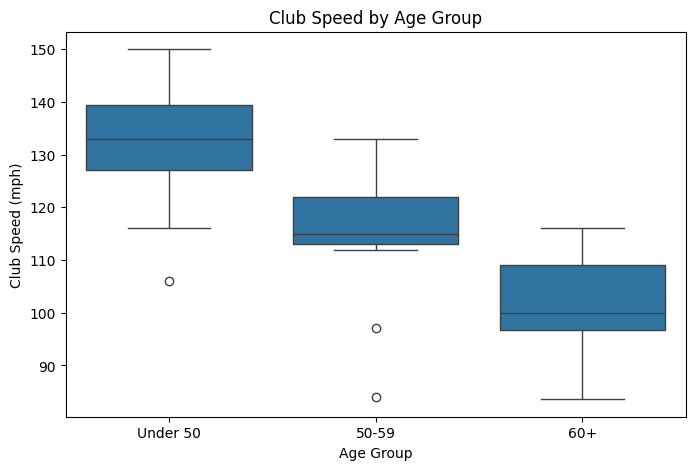

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Age_Group",
    y="Speed"
)

plt.title("Club Speed by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Club Speed (mph)")
plt.show()

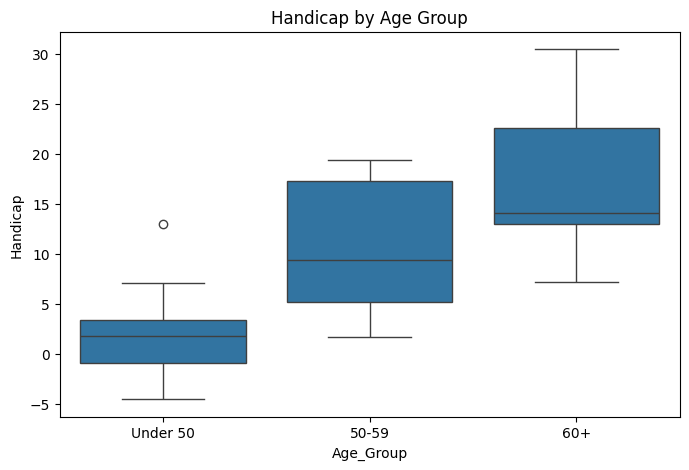

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Age_Group",
    y="Handicap"
)

plt.title("Handicap by Age Group")
plt.show()

/tmp/ipykernel_4265/2896070257.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby("Age_Group")["Carry"].mean()


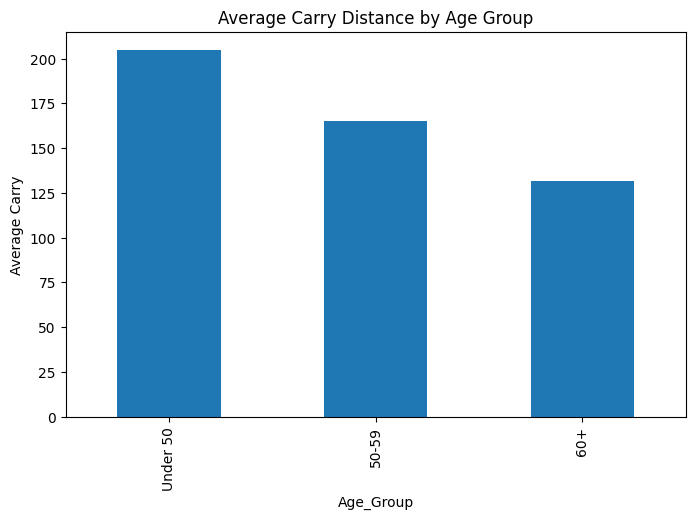

In [49]:
means = df.groupby("Age_Group")["Carry"].mean()

means.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Average Carry")
plt.title("Average Carry Distance by Age Group")

plt.show()

In [50]:
from scipy.stats import f_oneway

under50 = df[df["Age_Group"]=="Under 50"]["Carry"]

fifties = df[df["Age_Group"]=="50-59"]["Carry"]

sixties = df[df["Age_Group"]=="60+"]["Carry"]

F,p = f_oneway(
    under50,
    fifties,
    sixties
)

print("F =",F)
print("p =",p)

F = 32.26559620687813
p = 5.360922547061936e-10


In [51]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["Carry"],
    groups=df["Age_Group"],
    alpha=0.05
)

print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj   lower    upper  reject
-------------------------------------------------------
 50-59      60+ -33.4476 0.0176 -61.9356 -4.9595   True
 50-59 Under 50  39.7527 0.0006  15.6316 63.8737   True
   60+ Under 50  73.2002    0.0  50.5244 95.8761   True
-------------------------------------------------------


In [52]:
F,p = f_oneway(
    df[df["Age_Group"]=="Under 50"]["Speed"],
    df[df["Age_Group"]=="50-59"]["Speed"],
    df[df["Age_Group"]=="60+"]["Speed"]
)